In [1]:
from pathlib import Path
from IPython.display import display

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120

INT_COLS = ['threads', 'cs_work', 'read_pct', 'total_ops', 'read_ops', 'write_ops']
FLOAT_COLS = ['ops_s', 'ns_op', 'fairness_min', 'fairness_max', 'fairness_ratio']

def resolve_csv(name):
    for base in [Path('.'), Path('results')]:
        path = base / name
        if path.exists():
            return path
    raise FileNotFoundError(name)

FILES = {
    'x86_fixed': resolve_csv('x86_fixed_occ.csv'),
    'x86_old': resolve_csv('optimized_x86_lockbench.csv'),
    'arm': resolve_csv('optimized_arm_lockbench.csv'),
}

def load_lockbench_csv(path, dataset, platform):
    df = pd.read_csv(path, sep=';', decimal=',')
    for col in INT_COLS:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')
    for col in FLOAT_COLS:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df['ops_m'] = df['ops_s'] / 1e6
    df['dataset'] = dataset
    df['platform'] = platform
    return df

x86_fixed = load_lockbench_csv(FILES['x86_fixed'], 'x86_fixed', 'intel')
x86_old = load_lockbench_csv(FILES['x86_old'], 'x86_old', 'intel')
arm = load_lockbench_csv(FILES['arm'], 'arm', 'arm')
all_runs = pd.concat([x86_fixed, x86_old, arm], ignore_index=True)

def agg(df, group_cols):
    return (
        df.groupby(group_cols)
          .agg(
              runs=('ops_m', 'size'),
              ops_m_mean=('ops_m', 'mean'),
              ops_m_std=('ops_m', 'std'),
              ns_mean=('ns_op', 'mean'),
              fair_mean=('fairness_ratio', 'mean'),
              fair_std=('fairness_ratio', 'std'),
          )
          .reset_index()
    )

print('New x86 fixed sweep:')
print('  locks    :', sorted(x86_fixed['lock'].unique()))
print('  workloads:', sorted(x86_fixed['workload'].unique()))
print('  threads  :', sorted(x86_fixed['threads'].dropna().astype(int).unique().tolist()))
print('  read_pct :', sorted(x86_fixed['read_pct'].dropna().astype(int).unique().tolist()))
print()
print('Overlap files:')
for name, df in [('x86_old', x86_old), ('arm', arm)]:
    threads = sorted(df['threads'].dropna().astype(int).unique().tolist())
    read_pct = sorted(df['read_pct'].dropna().astype(int).unique().tolist())
    print(f"  {name:7s} threads={threads} read_pct={read_pct}")

display(
    agg(x86_fixed, ['workload', 'lock', 'read_pct'])
      .sort_values(['workload', 'lock', 'read_pct'])
      .reset_index(drop=True)
)


New x86 fixed sweep:
  locks    : ['cas', 'occ', 'rcu', 'rw', 'tas', 'ticket', 'ttas']
  workloads: ['mutex', 'rcu', 'rw']
  threads  : [1, 2, 4, 6, 8, 16, 32]
  read_pct : [0, 50, 100]

Overlap files:
  x86_old threads=[1, 2, 4, 6] read_pct=[80, 90, 95, 100]
  arm     threads=[1, 2, 4, 6] read_pct=[80, 90, 95, 100]


,workload,lock,read_pct,runs,ops_m_mean,ops_m_std,ns_mean,fair_mean,fair_std
0,mutex,cas,100,35,20.137129,33.884602,218.916844,0.524708,0.241891
1,mutex,occ,100,35,11.580028,17.032869,281.457664,0.479302,0.335674
2,mutex,rw,100,35,20.198580,35.393708,430.990190,0.543847,0.271999
3,mutex,tas,100,35,20.554275,36.720502,423.362059,0.500502,0.266059
4,mutex,ticket,100,35,18.786877,40.075555,418.008226,0.946784,0.140900
5,mutex,ttas,100,35,21.988031,38.096578,229.788050,0.494580,0.255480
6,rcu,rcu,0,35,6.401035,9.578902,365.552583,0.380558,0.376007
7,rcu,rcu,50,35,8.528773,13.085533,298.855589,0.695301,0.230875
8,rcu,rcu,100,35,1041.462997,882.706194,2.316909,0.896417,0.176041
9,rw,occ,0,35,9.519739,16.401545,385.352459,0.598918,0.267704


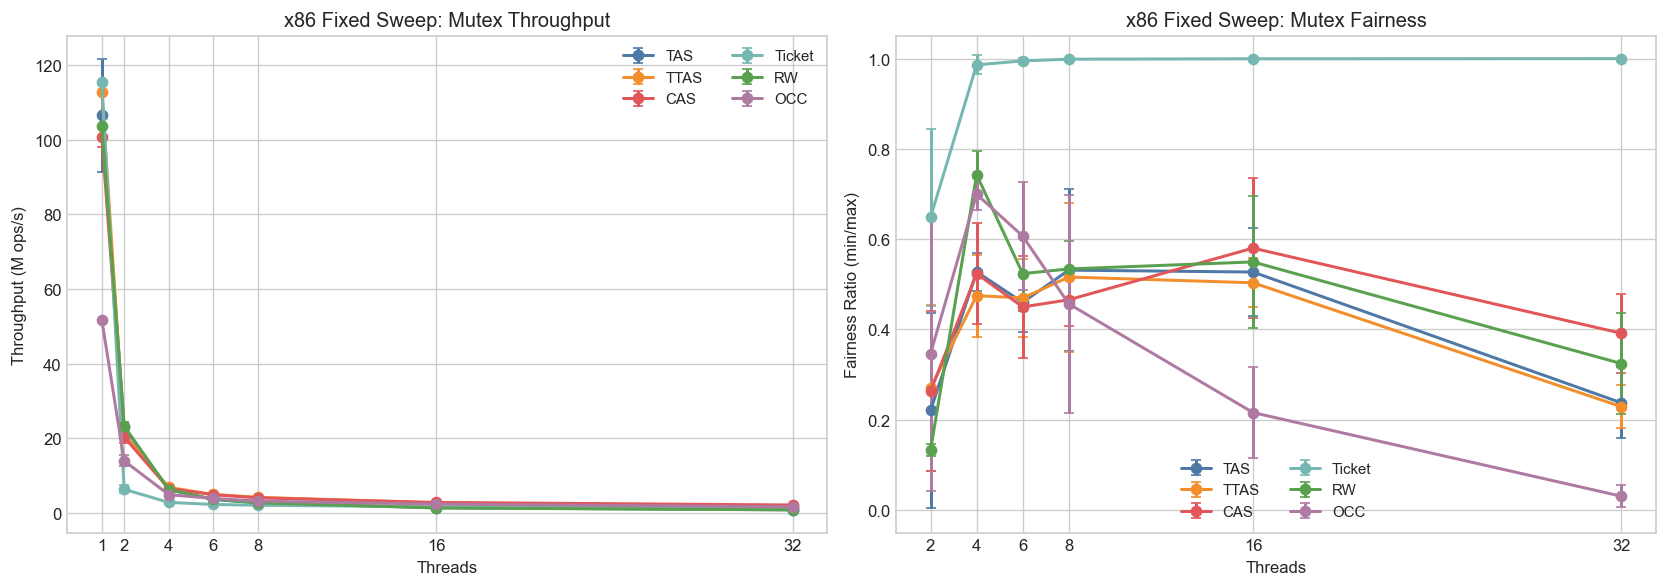

lock,CAS,OCC,RW,TAS,Ticket,TTAS
threads,,,,,,
1,100.676,51.590,103.764,106.561,115.459,112.759
2,20.254,13.896,23.219,22.907,6.257,21.030
4,6.465,4.816,6.187,6.160,2.745,6.752
6,4.803,3.819,3.578,3.541,2.199,4.888
8,3.971,3.096,2.646,2.643,1.976,4.116
16,2.738,2.272,1.252,1.311,1.568,2.599
32,2.053,1.571,0.745,0.757,1.302,1.773


In [2]:
mutex = x86_fixed[(x86_fixed['workload'] == 'mutex') & (x86_fixed['cs_work'] == 0)].copy()
g_mutex = agg(mutex, ['lock', 'threads']).sort_values(['lock', 'threads'])

LOCK_ORDER = ['tas', 'ttas', 'cas', 'ticket', 'rw', 'occ']
LOCK_LABELS = {
    'tas': 'TAS',
    'ttas': 'TTAS',
    'cas': 'CAS',
    'ticket': 'Ticket',
    'rw': 'RW',
    'occ': 'OCC',
}
LOCK_COLORS = {
    'tas': '#4e79a7',
    'ttas': '#f28e2b',
    'cas': '#e15759',
    'ticket': '#76b7b2',
    'rw': '#59a14f',
    'occ': '#af7aa1',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for lock in LOCK_ORDER:
    sub = g_mutex[g_mutex['lock'] == lock]
    if sub.empty:
        continue
    axes[0].errorbar(
        sub['threads'], sub['ops_m_mean'], yerr=sub['ops_m_std'],
        label=LOCK_LABELS[lock], color=LOCK_COLORS[lock], marker='o', linewidth=1.8, capsize=3,
    )
    fair = sub[sub['threads'] > 1]
    axes[1].errorbar(
        fair['threads'], fair['fair_mean'], yerr=fair['fair_std'],
        label=LOCK_LABELS[lock], color=LOCK_COLORS[lock], marker='o', linewidth=1.8, capsize=3,
    )

axes[0].set_title('x86 Fixed Sweep: Mutex Throughput')
axes[0].set_xlabel('Threads')
axes[0].set_ylabel('Throughput (M ops/s)')
axes[0].set_xticks([1, 2, 4, 6, 8, 16, 32])
axes[0].legend(fontsize=9, ncol=2)

axes[1].set_title('x86 Fixed Sweep: Mutex Fairness')
axes[1].set_xlabel('Threads')
axes[1].set_ylabel('Fairness Ratio (min/max)')
axes[1].set_xticks([2, 4, 6, 8, 16, 32])
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend(fontsize=9, ncol=2)

fig.tight_layout()
plt.show()

display(
    g_mutex[g_mutex['threads'].isin([1, 2, 4, 6, 8, 16, 32])]
      .pivot(index='threads', columns='lock', values='ops_m_mean')
      .rename(columns=LOCK_LABELS)
      .round(3)
)


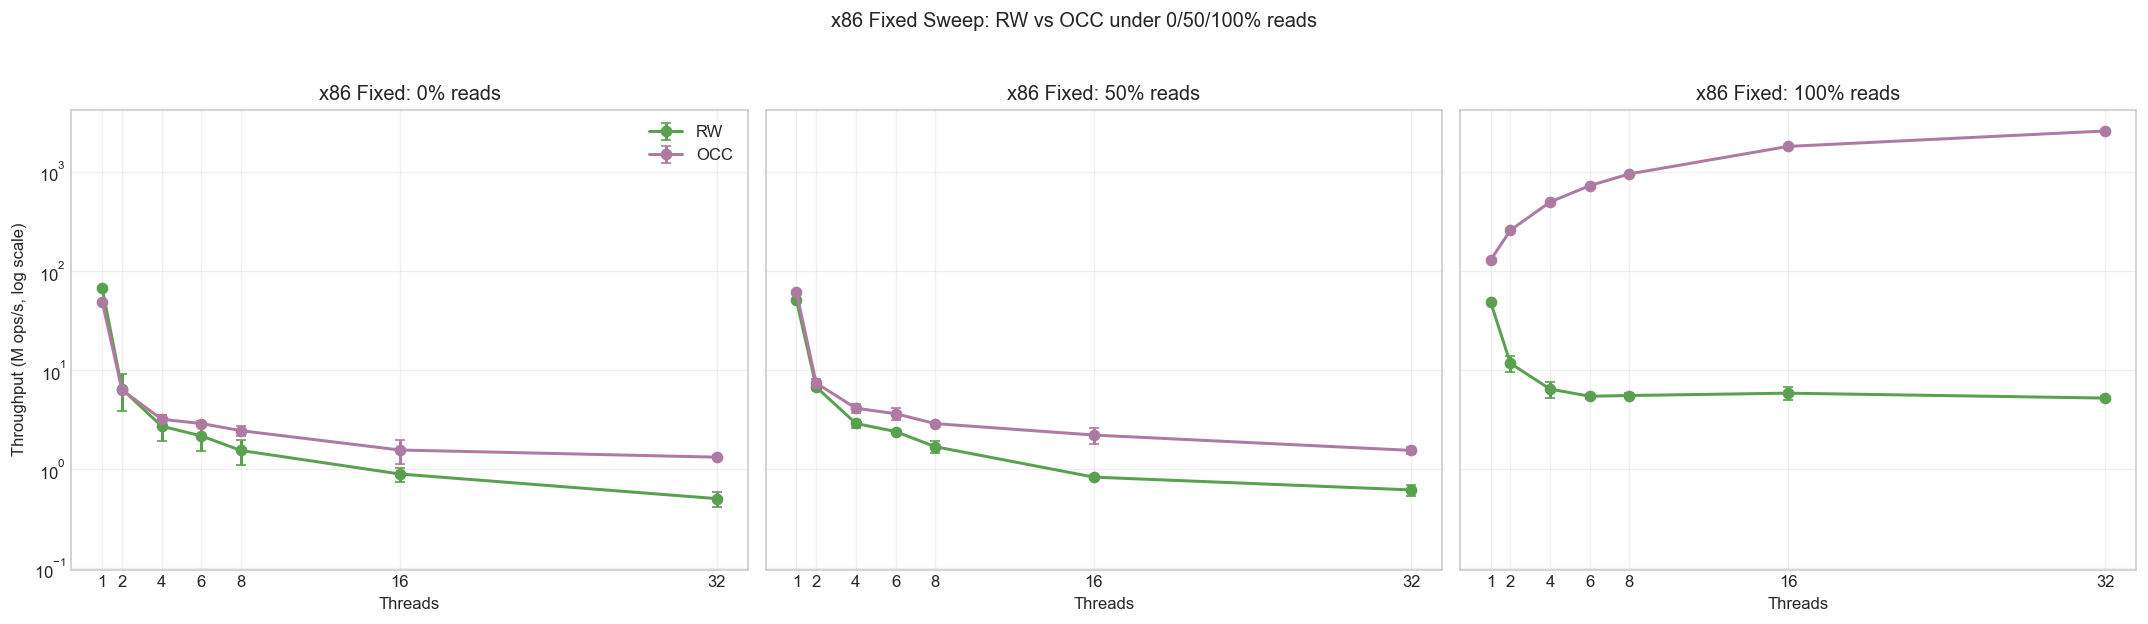

lock                   occ      rw  occ_over_rw
read_pct threads                               
0        1          48.939  67.119        0.729
         2           6.300   6.432        0.979
         4           3.187   2.711        1.176
         6           2.887   2.164        1.334
         8           2.445   1.542        1.585
         16          1.560   0.894        1.746
         32          1.320   0.504        2.621
50       1          61.644  50.966        1.210
         2           7.381   6.749        1.094
         4           4.122   2.892        1.425
         6           3.627   2.396        1.514
         8           2.882   1.684        1.711
         16          2.208   0.830        2.659
         32          1.546   0.617        2.506
100      1         128.738  48.827        2.637
         2         257.778  11.690       22.052
         4         496.662   6.432       77.214
         6         727.124   5.441      133.645
         8         955.092   5.536      172.517
         16       1809.028   5.845      309.524
         32       2591.362   5.215      496.925

Interpretation: at 100% reads, OCC is measuring its optimistic read fast path, so very large OCC/RW ratios are expected.


In [ ]:
rw_fixed = x86_fixed[(x86_fixed['workload'] == 'rw') & (x86_fixed['lock'].isin(['rw', 'occ']))].copy()
g_rw_fixed = agg(rw_fixed, ['read_pct', 'lock', 'threads']).sort_values(['read_pct', 'lock', 'threads'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, read_pct in zip(axes, [0, 50, 100]):
    for lock in ['rw', 'occ']:
        sub = g_rw_fixed[(g_rw_fixed['read_pct'] == read_pct) & (g_rw_fixed['lock'] == lock)]
        ax.errorbar(
            sub['threads'], sub['ops_m_mean'], yerr=sub['ops_m_std'],
            label=LOCK_LABELS[lock], color=LOCK_COLORS[lock], marker='o', linewidth=1.8, capsize=3,
        )
    ax.set_title(f'x86 Fixed: {read_pct}% reads')
    ax.set_xlabel('Threads')
    ax.set_xticks([1, 2, 4, 6, 8, 16, 32])
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Throughput (M ops/s, log scale)')
axes[0].legend()
fig.suptitle('x86 Fixed Sweep: RW vs OCC under 0/50/100% reads', y=1.03)
fig.tight_layout()
plt.show()

ratio = (
    g_rw_fixed.pivot(index=['read_pct', 'threads'], columns='lock', values='ops_m_mean')
              .assign(occ_over_rw=lambda d: d['occ'] / d['rw'])
              .round(3)
)
display(ratio)

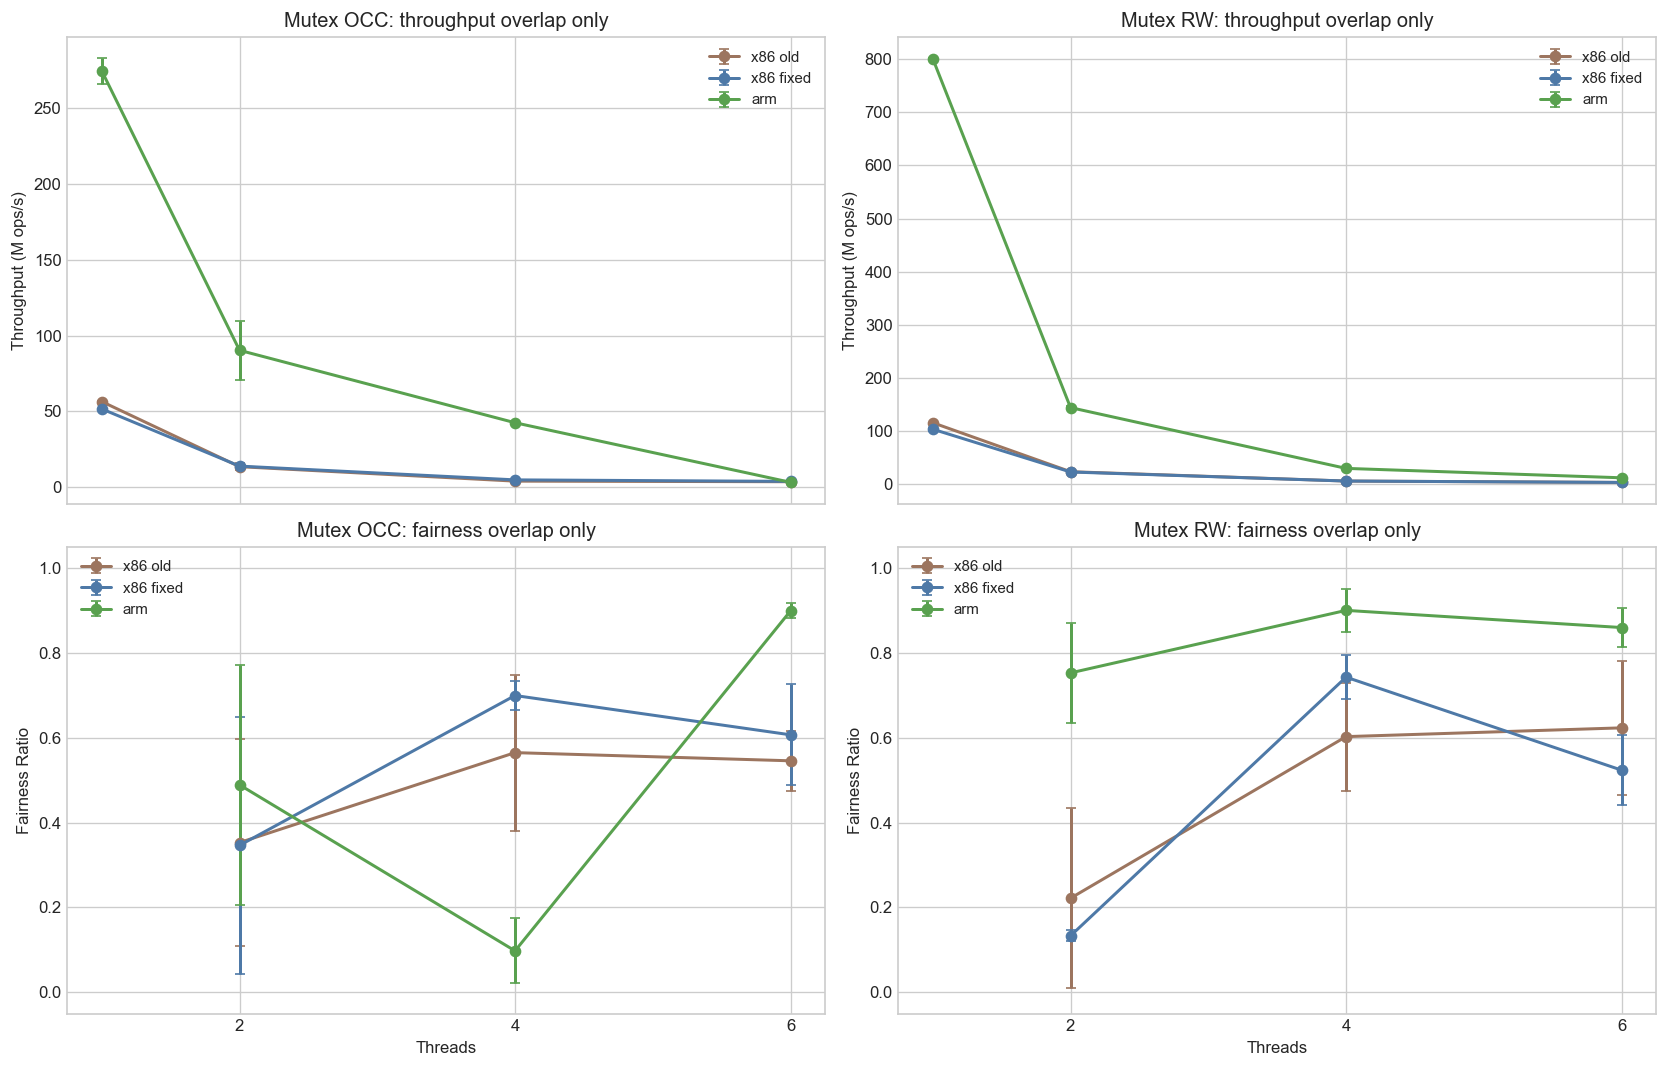

dataset,arm,x86_fixed,x86_old,fixed_vs_old,fixed_vs_arm
threads,,,,,
1,274.476,51.590,56.444,0.914,0.188
2,90.244,13.896,13.521,1.028,0.154
4,42.494,4.816,3.985,1.208,0.113
6,3.201,3.819,3.598,1.061,1.193


dataset,arm,x86_fixed,x86_old,fixed_vs_old,fixed_vs_arm
threads,,,,,
1,800.892,103.764,115.934,0.895,0.130
2,144.361,23.219,23.765,0.977,0.161
4,30.006,6.187,6.171,1.003,0.206
6,12.296,3.578,3.542,1.010,0.291


dataset         arm  x86_fixed  x86_old
lock threads                           
occ  2        0.489      0.346    0.353
     4        0.098      0.699    0.565
     6        0.899      0.607    0.546
rw   2        0.753      0.133    0.222
     4        0.900      0.743    0.603
     6        0.860      0.524    0.623

In [5]:
overlap = all_runs[
    (all_runs['workload'] == 'mutex')
    & (all_runs['lock'].isin(['occ', 'rw']))
    & (all_runs['threads'].isin([1, 2, 4, 6]))
].copy()
g_overlap = agg(overlap, ['dataset', 'lock', 'threads']).sort_values(['lock', 'dataset', 'threads'])

DATASET_ORDER = ['x86_old', 'x86_fixed', 'arm']
DATASET_LABELS = {
    'x86_old': 'x86 old',
    'x86_fixed': 'x86 fixed',
    'arm': 'arm',
}
DATASET_COLORS = {
    'x86_old': '#9c755f',
    'x86_fixed': '#4e79a7',
    'arm': '#59a14f',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
for col, lock in enumerate(['occ', 'rw']):
    for dataset in DATASET_ORDER:
        sub = g_overlap[(g_overlap['lock'] == lock) & (g_overlap['dataset'] == dataset)]
        axes[0, col].errorbar(
            sub['threads'], sub['ops_m_mean'], yerr=sub['ops_m_std'],
            label=DATASET_LABELS[dataset], color=DATASET_COLORS[dataset], marker='o', linewidth=1.8, capsize=3,
        )
        fair = sub[sub['threads'] > 1]
        axes[1, col].errorbar(
            fair['threads'], fair['fair_mean'], yerr=fair['fair_std'],
            label=DATASET_LABELS[dataset], color=DATASET_COLORS[dataset], marker='o', linewidth=1.8, capsize=3,
        )

    axes[0, col].set_title(f'Mutex {LOCK_LABELS[lock]}: throughput overlap only')
    axes[0, col].set_ylabel('Throughput (M ops/s)')
    axes[0, col].set_xticks([1, 2, 4, 6])
    axes[0, col].legend(fontsize=9)

    axes[1, col].set_title(f'Mutex {LOCK_LABELS[lock]}: fairness overlap only')
    axes[1, col].set_xlabel('Threads')
    axes[1, col].set_ylabel('Fairness Ratio')
    axes[1, col].set_xticks([2, 4, 6])
    axes[1, col].set_ylim(-0.05, 1.05)
    axes[1, col].legend(fontsize=9)

fig.tight_layout()
plt.show()

occ_overlap = (
    g_overlap[g_overlap['lock'] == 'occ']
      .pivot(index='threads', columns='dataset', values='ops_m_mean')
      .assign(
          fixed_vs_old=lambda d: d['x86_fixed'] / d['x86_old'],
          fixed_vs_arm=lambda d: d['x86_fixed'] / d['arm'],
      )
      .round(3)
)
rw_overlap = (
    g_overlap[g_overlap['lock'] == 'rw']
      .pivot(index='threads', columns='dataset', values='ops_m_mean')
      .assign(
          fixed_vs_old=lambda d: d['x86_fixed'] / d['x86_old'],
          fixed_vs_arm=lambda d: d['x86_fixed'] / d['arm'],
      )
      .round(3)
)

display(occ_overlap)
display(rw_overlap)

fair_overlap = (
    g_overlap[g_overlap['threads'] > 1]
      .pivot(index=['lock', 'threads'], columns='dataset', values='fair_mean')
      .round(3)
)
display(fair_overlap)
